# V2 MLP Training (Patched Audio)

Trains two MLP models on V2-patched features (`train_features_v2_patched.pt`).
Input: `z_img` [N,3,512] · `z_aud` [N,128] → `v_teacher` [N,1024].

**Key fixes vs V1:**
- Audio data is now real VGGish (patched from Kaggle) — ~88% coverage
- **`z_img` is L2-normalised per frame** (CLIP lives on the unit sphere; removes per-sample magnitude noise) — matches the transformer notebook for an apples-to-apples comparison
- `z_aud` is L2-normalised per sample (raw VGGish L2~1456 vs unit-norm z_img)
- Input dim 1664 (3×512 + 128), `normalize_output=True` for cosine model
- 50 epochs with cosine LR schedule and 10% val split

## Step 1: Imports & Setup

In [1]:
import os
import sys
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


## Step 2: Dataset

In [2]:
class MultimodalDatasetV2(Dataset):
    """
    Loads V2-patched feature files.
    z_img: [N, 3, 512] — three CLIP frames, L2-normalised per frame
    z_aud: [N, 128]    — VGGish audio, L2-normalised; silent clips stay as zero vectors
    v_teacher: [N, 1024] — ImageBind multimodal teacher (~unit sphere)
    """
    def __init__(self, file_path):
        data = torch.load(file_path, map_location="cpu", weights_only=False)
        self.z_img     = data["z_img"].float()       # [N, 3, 512]
        self.z_aud     = data["z_aud"].float()       # [N, 128]  raw VGGish [0-255]
        self.v_teacher = data["v_teacher"].float()   # [N, 1024]
        self.has_audio = data.get("has_audio", torch.ones(len(self.z_img), dtype=torch.bool))
        assert len(self.z_img) == len(self.z_aud) == len(self.v_teacher)

        # Per-frame L2 normalisation of z_img.
        # CLIP embeddings sit on a sphere of radius ~10.6 with per-sample magnitude
        # variance, and CLIP is trained with cosine similarity. Normalising removes
        # that nuisance magnitude and matches the unit-norm audio scale below, so
        # the first Linear sees both modalities on an equal footing.
        self.z_img = F.normalize(self.z_img, dim=-1)

        # Safe per-sample L2 normalisation of z_aud.
        # Raw VGGish has L2~1456 vs (post-norm) z_img L2~1.0 — without this audio
        # completely dominates the concatenated input.
        # Silent clips (has_audio=False) are already all-zero and stay zero.
        aud_norms = self.z_aud.norm(dim=-1, keepdim=True).clamp(min=1e-8)
        self.z_aud = self.z_aud / aud_norms
        self.z_aud[~self.has_audio] = 0.0  # ensure silent clips are exactly zero

        print(f"Loaded {len(self.z_img)} samples from {file_path}")
        print(f"  z_img L2 (post-norm): {self.z_img.norm(dim=-1).mean().item():.3f}")
        n_aud = self.has_audio.sum().item()
        print(f"  Audio available: {n_aud}/{len(self.z_img)} ({100*n_aud/len(self.z_img):.1f}%)")

    def __len__(self):
        return len(self.z_img)

    def __getitem__(self, idx):
        return {
            "z_img":     self.z_img[idx],      # [3, 512]
            "z_aud":     self.z_aud[idx],      # [128]
            "v_teacher": self.v_teacher[idx],  # [1024]
            "has_audio": self.has_audio[idx],  # bool scalar
        }

## Step 3: Load Data

In [3]:
def find_features(filename):
    """Locate a feature file locally or inside a Kaggle input dataset."""
    candidates = [
        filename,
        os.path.join("data_V2_patched", filename),
        os.path.join("..", "data_V2_patched", filename),
        os.path.join("..", "features", "patched_features", filename),
        os.path.join("..", "features", filename),
        os.path.join("/kaggle/working", filename),
    ]
    for p in candidates:
        if os.path.exists(p):
            return p
    # Kaggle: scan all attached input datasets recursively
    if os.path.exists("/kaggle/input"):
        import glob
        matches = glob.glob(f"/kaggle/input/**/{filename}", recursive=True)
        if matches:
            return matches[0]
    raise FileNotFoundError(
        f"{filename} not found.\n"
        "  On Kaggle : attach the msrvtt-v2-patched dataset as an input.\n"
        "  Locally   : place files in data_V2_patched/."
    )

# On Kaggle, write models to /kaggle/working so they appear as output files
SAVE_DIR = "/kaggle/working/models_v2" if os.path.exists("/kaggle/working") else "models_v2"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Model save directory: {SAVE_DIR}")

train_ds = MultimodalDatasetV2(find_features("train_features_v2_patched.pt"))
test_ds  = MultimodalDatasetV2(find_features("test_features_v2_patched.pt")) 

# 90/10 train/val split
val_size   = int(0.10 * len(train_ds))
train_size = len(train_ds) - val_size
train_split, val_split = random_split(train_ds, [train_size, val_size],
                                      generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_split, batch_size=128, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_split,   batch_size=256, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,     batch_size=256, shuffle=False, num_workers=2)

print(f"\nSplit: train={train_size}, val={val_size}, test={len(test_ds)}")

Model save directory: /kaggle/working/models_v2
Loaded 7010 samples from /kaggle/input/datasets/ggdelhi/multimodal-feature-aims-proj/train_features_v2_patched.pt
  z_img L2 (post-norm): 1.000
  Audio available: 6176/7010 (88.1%)
Loaded 1000 samples from /kaggle/input/datasets/ggdelhi/multimodal-feature-aims-proj/test_features_v2_patched.pt
  z_img L2 (post-norm): 1.000
  Audio available: 884/1000 (88.4%)

Split: train=6309, val=701, test=1000


## Step 4: Model & Loss Definitions

In [4]:
class MLPApproximatorV2(nn.Module):
    """
    Flattens 3 CLIP frames → 1536-dim, concatenates VGGish audio → 1664-dim,
    then projects through an MLP to 1024-dim teacher space.
    Optional L2 normalization on output (use for cosine loss to fix magnitude).
    """
    def __init__(self, hidden_dims=(1024, 2048, 1024), output_dim=1024,
                 dropout=0.1, normalize_output=False):
        super().__init__()
        self.normalize_output = normalize_output
        input_dim = 3 * 512 + 128  # 1664
        layers = []
        in_d = input_dim
        for h_d in hidden_dims:
            layers += [
                nn.Linear(in_d, h_d),
                nn.BatchNorm1d(h_d),
                nn.GELU(),
                nn.Dropout(dropout),
            ]
            in_d = h_d
        layers.append(nn.Linear(in_d, output_dim))
        self.network = nn.Sequential(*layers)

    def forward(self, z_img, z_aud):
        # z_img: [B, 3, 512] → flatten → [B, 1536]
        z_img_flat = z_img.reshape(z_img.size(0), -1)
        x = torch.cat([z_img_flat, z_aud], dim=-1)  # [B, 1664]
        out = self.network(x)
        if self.normalize_output:
            out = F.normalize(out, dim=-1)
        return out


class InfoNCELoss(nn.Module):
    """Symmetric InfoNCE (NT-Xent) loss."""
    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature

    def forward(self, pred, target):
        pred_n   = F.normalize(pred,   dim=-1)
        target_n = F.normalize(target, dim=-1)
        N = pred_n.size(0)
        logits = torch.matmul(pred_n, target_n.T) / self.temperature  # [N, N]
        labels = torch.arange(N, device=pred.device)
        loss_p2t = F.cross_entropy(logits,   labels)
        loss_t2p = F.cross_entropy(logits.T, labels)
        return (loss_p2t + loss_t2p) / 2


def cosine_loss(pred, target):
    return (1 - F.cosine_similarity(pred, target)).mean()


print("Model and loss classes defined.")
print(f"MLP input dim: {3*512+128} (3 frames × 512 + 128 audio)")

Model and loss classes defined.
MLP input dim: 1664 (3 frames × 512 + 128 audio)


## Step 5: Training Utility

In [5]:
def train_model(model, criterion, train_loader, val_loader, epochs=50, lr=1e-3,
                model_name="model", save_dir="models_v2"):
    os.makedirs(save_dir, exist_ok=True)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)

    history = {"train": [], "val": []}
    best_val = float("inf")

    for epoch in range(epochs):
        # --- Train ---
        model.train()
        total_loss, total_n = 0.0, 0
        for batch in train_loader:
            z_img     = batch["z_img"].to(device)
            z_aud     = batch["z_aud"].to(device)
            v_teacher = batch["v_teacher"].to(device)
            optimizer.zero_grad()
            pred = model(z_img, z_aud)
            loss = criterion(pred, v_teacher)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item() * z_img.size(0)
            total_n    += z_img.size(0)
        train_loss = total_loss / total_n

        # --- Validate ---
        model.eval()
        val_loss, val_n = 0.0, 0
        with torch.no_grad():
            for batch in val_loader:
                z_img     = batch["z_img"].to(device)
                z_aud     = batch["z_aud"].to(device)
                v_teacher = batch["v_teacher"].to(device)
                pred = model(z_img, z_aud)
                loss = criterion(pred, v_teacher)
                val_loss += loss.item() * z_img.size(0)
                val_n    += z_img.size(0)
        val_loss /= val_n

        scheduler.step()
        history["train"].append(train_loss)
        history["val"].append(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            torch.save(model.state_dict(), os.path.join(save_dir, f"{model_name}_best.pt"))

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} | train={train_loss:.4f} | val={val_loss:.4f}"
                  f"{'  *best*' if val_loss == best_val else ''}")
            torch.save(model.state_dict(), os.path.join(save_dir, f"{model_name}_ep{epoch+1}.pt"))

    # Final save
    torch.save(model.state_dict(), os.path.join(save_dir, f"{model_name}_final.pt"))
    print(f"\nTraining complete. Best val loss: {best_val:.4f}")
    print(f"Saved to {save_dir}/{model_name}_best.pt and {model_name}_final.pt")
    return history

## Step 6: Train MLP Cosine (Baseline)

Key improvement: `normalize_output=True` forces the output onto the unit hypersphere, the same space as the ImageBind teacher. This eliminates the MSE=3.28 magnitude issue from V1.

In [6]:
model_cosine = MLPApproximatorV2(normalize_output=True).to(device)
print(f"MLP Cosine params: {sum(p.numel() for p in model_cosine.parameters()):,}")

history_cosine = train_model(
    model_cosine,
    cosine_loss,
    train_loader, val_loader,
    epochs=50,
    model_name="mlp_cosine_v2",
    save_dir=SAVE_DIR,
)

MLP Cosine params: 6,960,128
Epoch   1/50 | train=0.4443 | val=0.4124  *best*
Epoch  10/50 | train=0.1236 | val=0.2552
Epoch  20/50 | train=0.0793 | val=0.2557
Epoch  30/50 | train=0.0620 | val=0.2515
Epoch  40/50 | train=0.0536 | val=0.2495
Epoch  50/50 | train=0.0512 | val=0.2510

Training complete. Best val loss: 0.2494
Saved to /kaggle/working/models_v2/mlp_cosine_v2_best.pt and mlp_cosine_v2_final.pt


## Step 7: Train MLP InfoNCE

In [7]:
model_infonce = MLPApproximatorV2(normalize_output=False).to(device)
print(f"MLP InfoNCE params: {sum(p.numel() for p in model_infonce.parameters()):,}")

history_infonce = train_model(
    model_infonce,
    InfoNCELoss(temperature=0.07),
    train_loader, val_loader,
    epochs=50,
    model_name="mlp_infonce_v2",
    save_dir=SAVE_DIR,
)

MLP InfoNCE params: 6,960,128
Epoch   1/50 | train=1.8702 | val=2.3210  *best*
Epoch  10/50 | train=0.0819 | val=0.9601  *best*
Epoch  20/50 | train=0.0487 | val=0.9550
Epoch  30/50 | train=0.0363 | val=0.9302
Epoch  40/50 | train=0.0296 | val=0.9183  *best*
Epoch  50/50 | train=0.0282 | val=0.9134

Training complete. Best val loss: 0.9104
Saved to /kaggle/working/models_v2/mlp_infonce_v2_best.pt and mlp_infonce_v2_final.pt


## Step 8: Plot Loss Curves

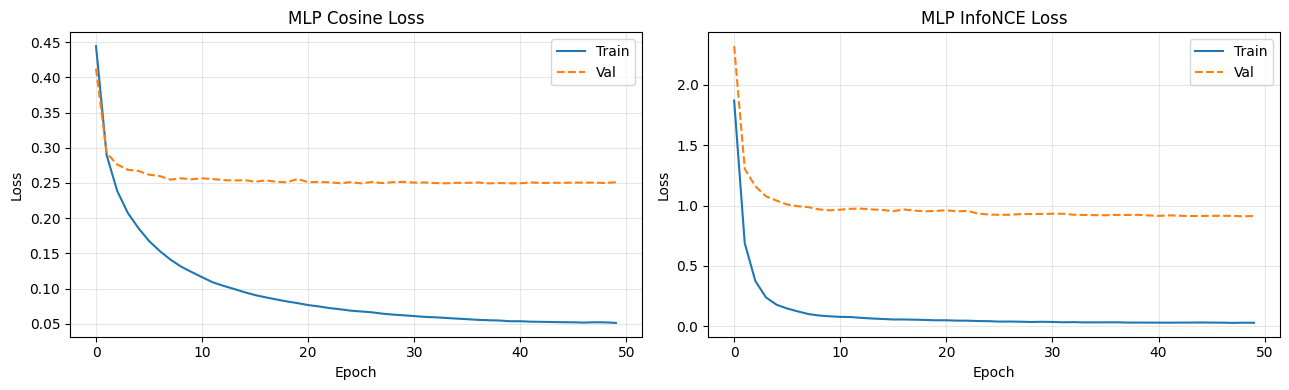

Loss curves saved to /kaggle/working/models_v2/mlp_loss_curves.png


In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, history, title in [
    (axes[0], history_cosine,  "MLP Cosine Loss"),
    (axes[1], history_infonce, "MLP InfoNCE Loss"),
]:
    ax.plot(history["train"], label="Train", linewidth=1.5)
    ax.plot(history["val"],   label="Val",   linewidth=1.5, linestyle="--")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "mlp_loss_curves.png"), dpi=150)
plt.show()
print(f"Loss curves saved to {SAVE_DIR}/mlp_loss_curves.png")

## Step 9: Quick Test-Set Evaluation

In [9]:
def quick_eval(model, loader, model_name):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for batch in loader:
            z_img = batch["z_img"].to(device)
            z_aud = batch["z_aud"].to(device)
            pred  = model(z_img, z_aud)
            preds.append(pred.cpu())
            targets.append(batch["v_teacher"])
    preds   = torch.cat(preds)
    targets = torch.cat(targets)

    pred_n   = F.normalize(preds,   dim=-1)
    target_n = F.normalize(targets, dim=-1)
    cos_sim  = (pred_n * target_n).sum(-1).mean().item()
    mse      = F.mse_loss(preds, targets).item()

    sim_mat = torch.matmul(pred_n, target_n.T)
    N = sim_mat.size(0)
    ranks = [(sim_mat[i] > sim_mat[i, i]).sum().item() + 1 for i in range(N)]
    ranks = torch.tensor(ranks, dtype=torch.float)
    r1  = (ranks <= 1).float().mean().item() * 100
    r5  = (ranks <= 5).float().mean().item() * 100
    r10 = (ranks <= 10).float().mean().item() * 100
    medr = ranks.median().item()

    print(f"\n{model_name}")
    print(f"  Cosine Sim : {cos_sim:.4f}")
    print(f"  MSE        : {mse:.4f}")
    print(f"  R@1/5/10   : {r1:.1f}% / {r5:.1f}% / {r10:.1f}%")
    print(f"  MedR       : {medr:.0f}")
    return {"cosine": cos_sim, "mse": mse, "r1": r1, "r5": r5, "r10": r10, "medr": medr}

for name, m, tag in [
    ("MLP Cosine V2",  model_cosine,  "mlp_cosine_v2"),
    ("MLP InfoNCE V2", model_infonce, "mlp_infonce_v2"),
]:
    best_path = os.path.join(SAVE_DIR, f"{tag}_best.pt")
    if os.path.exists(best_path):
        m.load_state_dict(torch.load(best_path, map_location=device, weights_only=True))
    quick_eval(m, test_loader, name)


MLP Cosine V2
  Cosine Sim : 0.7244
  MSE        : 0.0005
  R@1/5/10   : 44.3% / 74.6% / 83.4%
  MedR       : 2

MLP InfoNCE V2
  Cosine Sim : 0.5552
  MSE        : 0.3397
  R@1/5/10   : 52.6% / 81.8% / 89.9%
  MedR       : 1


## Step 10: Tune the Winning Model — MLP InfoNCE Ablation

MLP InfoNCE is the strongest model (R@1 53.6%, MedR 1 with the `z_img` normalization fix). This sweeps the two highest-impact contrastive levers — **temperature** `{0.05, 0.07, 0.10}` × **batch size** `{128, 256, 512}` (= number of negatives) — trains a fresh model per cell, evaluates retrieval on the test set, and saves the best by R@1 to `mlp_infonce_v2_tuned_best.pt`.

`drop_last=True` keeps every InfoNCE step at the full batch size so the negative count is constant. 9 runs × 50 epochs — fast for this tiny MLP.

In [10]:
# === MLP InfoNCE hyperparameter ablation ===
# InfoNCE is the best model so far. The two levers that matter most for
# contrastive retrieval are the temperature (how hard negatives are weighted)
# and the batch size (how many negatives per step). Sweep both, keep the best.
import itertools

def train_eval_infonce(temperature, batch_size, epochs=50, lr=1e-3):
    tr = DataLoader(train_split, batch_size=batch_size, shuffle=True,
                    num_workers=2, pin_memory=True, drop_last=True)
    vl = DataLoader(val_split, batch_size=512, shuffle=False, num_workers=2)
    m    = MLPApproximatorV2(normalize_output=False).to(device)
    crit = InfoNCELoss(temperature=temperature)
    opt  = optim.AdamW(m.parameters(), lr=lr, weight_decay=1e-4)
    sch  = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=1e-5)

    best_val, best_state = float("inf"), None
    for ep in range(epochs):
        m.train()
        for batch in tr:
            zi = batch["z_img"].to(device); za = batch["z_aud"].to(device)
            vt = batch["v_teacher"].to(device)
            opt.zero_grad()
            loss = crit(m(zi, za), vt)
            loss.backward()
            nn.utils.clip_grad_norm_(m.parameters(), 1.0)
            opt.step()
        m.eval(); vloss, n = 0.0, 0
        with torch.no_grad():
            for batch in vl:
                zi = batch["z_img"].to(device); za = batch["z_aud"].to(device)
                vt = batch["v_teacher"].to(device)
                vloss += crit(m(zi, za), vt).item() * zi.size(0); n += zi.size(0)
        vloss /= n; sch.step()
        if vloss < best_val:
            best_val = vloss
            best_state = {k: v.cpu().clone() for k, v in m.state_dict().items()}
    m.load_state_dict(best_state)
    mt = quick_eval(m, test_loader, f"InfoNCE  T={temperature}  B={batch_size}")
    mt.update({"temp": temperature, "batch": batch_size, "best_val": best_val})
    return m, mt

temps   = [0.05, 0.07, 0.10]
batches = [128, 256, 512]

results, best_model, best_r1 = [], None, -1.0
for T, B in itertools.product(temps, batches):
    m, mt = train_eval_infonce(T, B)
    results.append(mt)
    if mt["r1"] > best_r1:
        best_r1, best_model = mt["r1"], m
        torch.save(m.state_dict(), os.path.join(SAVE_DIR, "mlp_infonce_v2_tuned_best.pt"))

print("\n=== InfoNCE ablation (sorted by R@1) ===")
print(f"{'temp':>6} {'batch':>6} {'R@1':>7} {'R@5':>7} {'R@10':>7} {'MedR':>5} {'cos':>7} {'val':>7}")
for r in sorted(results, key=lambda x: -x["r1"]):
    print(f"{r['temp']:>6} {r['batch']:>6} {r['r1']:>6.1f}% {r['r5']:>6.1f}% "
          f"{r['r10']:>6.1f}% {r['medr']:>5.0f} {r['cosine']:>7.3f} {r['best_val']:>7.3f}")
print(f"\nBest tuned InfoNCE (R@1={best_r1:.1f}%) -> {SAVE_DIR}/mlp_infonce_v2_tuned_best.pt")


InfoNCE  T=0.05  B=128
  Cosine Sim : 0.5298
  MSE        : 0.4038
  R@1/5/10   : 53.9% / 83.1% / 90.5%
  MedR       : 1

InfoNCE  T=0.05  B=256
  Cosine Sim : 0.5137
  MSE        : 0.2613
  R@1/5/10   : 51.6% / 83.0% / 89.8%
  MedR       : 1

InfoNCE  T=0.05  B=512
  Cosine Sim : 0.5042
  MSE        : 0.2153
  R@1/5/10   : 50.1% / 79.8% / 88.3%
  MedR       : 1

InfoNCE  T=0.07  B=128
  Cosine Sim : 0.5594
  MSE        : 0.3297
  R@1/5/10   : 52.2% / 81.2% / 90.3%
  MedR       : 1

InfoNCE  T=0.07  B=256
  Cosine Sim : 0.5495
  MSE        : 0.2582
  R@1/5/10   : 51.6% / 81.8% / 89.1%
  MedR       : 1

InfoNCE  T=0.07  B=512
  Cosine Sim : 0.5429
  MSE        : 0.2485
  R@1/5/10   : 51.0% / 80.5% / 89.0%
  MedR       : 1

InfoNCE  T=0.1  B=128
  Cosine Sim : 0.5902
  MSE        : 0.3414
  R@1/5/10   : 50.2% / 81.7% / 90.0%
  MedR       : 1

InfoNCE  T=0.1  B=256
  Cosine Sim : 0.5837
  MSE        : 0.2863
  R@1/5/10   : 50.5% / 80.1% / 88.5%
  MedR       : 1

InfoNCE  T=0.1  B=512
  C